# Term paper 2

## Part 1 — Data preprocessing (SCE)

In this part, I import and clean the SCE data.

I perform the following steps:
1. import and merge the yearly SCE extract files,
2. forward-fill selected variables that are only asked in the initial interview,
3. drop all observations from 2025,
4. drop observations with missing values in the variables used later,
5. remove outliers in the four expectations variables using the 1st and 99th percentiles,
6. create three binary optimism indicators.

To preserve a sufficiently large sample, I use a moderate set of individual-level SCE predictors in later parts of the analysis.

In [37]:
import numpy as np
import pandas as pd
from pathlib import Path
import yfinance as yf
import matplotlib.pyplot as plt

In [38]:
# Path to folder with the SCE data
data_path = Path('data')

# Yearly SCE extract files
sce_files = sorted(data_path.glob('sce_extract_*.csv'))

# Check that files were found
sce_files

[WindowsPath('data/sce_extract_2013.csv'),
 WindowsPath('data/sce_extract_2014.csv'),
 WindowsPath('data/sce_extract_2015.csv'),
 WindowsPath('data/sce_extract_2016.csv'),
 WindowsPath('data/sce_extract_2017.csv'),
 WindowsPath('data/sce_extract_2018.csv'),
 WindowsPath('data/sce_extract_2019.csv'),
 WindowsPath('data/sce_extract_2020.csv'),
 WindowsPath('data/sce_extract_2021.csv'),
 WindowsPath('data/sce_extract_2022.csv'),
 WindowsPath('data/sce_extract_2023.csv'),
 WindowsPath('data/sce_extract_2024.csv'),
 WindowsPath('data/sce_extract_2025.csv')]

In [39]:
def sample_summary(df):
    """
    Return a short summary of the sample.
    """
    summary = pd.Series({
        'individuals': df['userid'].nunique(),
        'observations': len(df),
        'survey_waves': df['wid'].nunique(),
        'first_date': df['date'].min(),
        'last_date': df['date'].max(),
    })
    
    return summary

In [40]:
# Load all yearly files and combine them into one DataFrame
df_list = []

for file in sce_files:
    df_year = pd.read_csv(file)
    df_list.append(df_year)

sce = pd.concat(df_list, ignore_index=True)

# Convert date column to datetime
sce['date'] = pd.to_datetime(sce['date'])

# Sort by individual and date
sce = sce.sort_values(['userid', 'date']).reset_index(drop=True)

In [41]:
# Summary of the raw sample
summary_initial = sample_summary(sce)
summary_initial

individuals                   23886
observations                 180268
survey_waves                    143
first_date      2013-06-01 00:00:00
last_date       2025-05-01 00:00:00
dtype: object

I next define the variables that I will use later in the analysis.

The four main continuous expectations variables are:
- `infl_1y`
- `house_price_change`
- `prob_unrate_up`
- `prob_stocks_up`

I also keep a moderate set of individual-level SCE predictors. I avoid variables with very large amounts of missing data so that the final sample remains large enough for the later prediction tasks.

In [42]:
# Continuous expectations variables used later
target_vars = [
    'infl_1y',
    'house_price_change',
    'prob_unrate_up',
    'prob_stocks_up',
]

# Individual-level SCE predictors used later
sce_feature_vars = [
    'financial_past_12m',
    'financial_12m',
    'credit_cond_past_12m',
    'credit_cond_12m',
    'prob_miss_paym_3m',
    'working',
    'hh_inc_change',
    'hh_spending_change',
    'taxes_change',
    'hh_inc_bin_rank',
    'age_init',
    'female',
    'hispanic',
    'black',
    'educ',
    'owner',
    'num_kids',
    'couple',
]

# Variables that are mainly asked in the initial wave and are carried forward
ffill_vars = [
    'age_init',
    'female',
    'hispanic',
    'black',
    'educ',
    'owner',
    'couple',
]

In [43]:
# Forward-fill selected variables within each individual
sce[ffill_vars] = sce.groupby('userid')[ffill_vars].ffill()

In [44]:
# Drop all survey waves from 2025
n_before = len(sce)

sce = sce[sce['date'].dt.year < 2025].copy()

n_after = len(sce)
dropped_2025 = n_before - n_after

print(f'Observations dropped from 2025: {dropped_2025}')

Observations dropped from 2025: 4167


In [45]:
# Keep only variables needed for the analysis
keep_vars = ['userid', 'wid', 'date'] + target_vars + sce_feature_vars
sce = sce[keep_vars].copy()

In [46]:
# Drop observations with missing values in variables used in the analysis
n_before = len(sce)

sce = sce.dropna().copy()

n_after = len(sce)
dropped_missing = n_before - n_after

print(f'Observations dropped due to missing values: {dropped_missing}')

Observations dropped due to missing values: 4649


In [47]:
# Remove outliers in the four main expectations variables
drop_counts = {}

for var in target_vars:
    p1 = sce[var].quantile(0.01)
    p99 = sce[var].quantile(0.99)
    
    n_before = len(sce)
    sce = sce[(sce[var] > p1) & (sce[var] < p99)].copy()
    n_after = len(sce)
    
    drop_counts[var] = {
        'P1': p1,
        'P99': p99,
        'dropped': n_before - n_after,
    }

drop_counts = pd.DataFrame(drop_counts).T
drop_counts

,P1,P99,dropped
infl_1y,-30.0,60.0,3573.0
house_price_change,-20.0,40.0,4599.0
prob_unrate_up,0.0,100.0,4294.0
prob_stocks_up,1.0,90.0,5148.0


In [48]:
# Create optimism indicator variables
sce['optimist_unrate'] = (sce['prob_unrate_up'] < 50).astype(int)
sce['optimist_stocks'] = (sce['prob_stocks_up'] > 50).astype(int)
sce['optimist_house_price'] = (sce['house_price_change'] > 0).astype(int)

In [49]:
# Summary of the final cleaned sample
summary_final = sample_summary(sce)
summary_final

individuals                   22015
observations                 153838
survey_waves                    139
first_date      2013-06-01 00:00:00
last_date       2024-12-31 00:00:00
dtype: object

In [50]:
# Compare initial and final sample
summary_table = pd.concat(
    [summary_initial.rename('Initial sample'),
     summary_final.rename('Final sample')],
    axis=1,
)

summary_table

,Initial sample,Final sample
individuals,23886,22015
observations,180268,153838
survey_waves,143,139
first_date,2013-06-01 00:00:00,2013-06-01 00:00:00
last_date,2025-05-01 00:00:00,2024-12-31 00:00:00


In [51]:
# Create a compact table with the number of dropped observations at each step
drop_summary = pd.DataFrame({
    'step': [
        'Drop 2025 observations',
        'Drop missing values',
        'Trim outliers: infl_1y',
        'Trim outliers: house_price_change',
        'Trim outliers: prob_unrate_up',
        'Trim outliers: prob_stocks_up',
    ],
    'dropped': [
        dropped_2025,
        dropped_missing,
        drop_counts.loc['infl_1y', 'dropped'],
        drop_counts.loc['house_price_change', 'dropped'],
        drop_counts.loc['prob_unrate_up', 'dropped'],
        drop_counts.loc['prob_stocks_up', 'dropped'],
    ]
})

drop_summary

,step,dropped
0,Drop 2025 observations,4167.0
1,Drop missing values,4649.0
2,Trim outliers: infl_1y,3573.0
3,Trim outliers: house_price_change,4599.0
4,Trim outliers: prob_unrate_up,4294.0
5,Trim outliers: prob_stocks_up,5148.0


In [52]:
# Save cleaned SCE data for later parts
sce.to_csv(data_path / 'sce_cleaned.csv', index=False)

### Discussion

The raw SCE sample contains 180,268 observations from 23,886 individuals. After dropping all observations from 2025, removing observations with missing values in the variables used in the analysis, and trimming outliers in the four main expectations variables, the final sample contains 153,838 observations from 22,015 individuals.

This final sample size is close to the assignment guideline of around 150,000 observations. I therefore consider the chosen set of SCE variables to be a reasonable balance between retaining useful information and avoiding an excessive loss of observations.

I define the optimism indicators in a natural way:
- `optimist_unrate = 1` if the respondent believes the probability of unemployment increasing is below 50,
- `optimist_stocks = 1` if the respondent believes the probability of stock prices increasing is above 50,
- `optimist_house_price = 1` if the respondent expects positive house price growth over the next 12 months.

These binary variables will be used later in the classification part of the term paper.

## Part 2 - Data preprocessing (macro/finance)

In this part, we merge macroeconomic and financial time series into the cleaned SCE data from Part 1.

We load the saved Yahoo Finance and FRED files from the `data` folder, resample the daily and weekly series to monthly frequency using the last observation in each month, and keep quarterly series at quarterly frequency.

To avoid look-ahead bias, monthly variables are matched using the previous month-end and quarterly variables using the previous quarter-end.

In [53]:
def load_series(filename, col_name):
    """
    Load a saved CSV file and rename its data column.
    """
    df = pd.read_csv(data_path / filename, parse_dates=[0], index_col=0)
    df.columns = [col_name]
    df.index.name = 'date'
    
    return df

In [54]:
# Load monthly / daily / weekly series
oil = load_series('oil_price.csv', 'oil_price')
sp500 = load_series('sp500.csv', 'sp500')
cpi = load_series('CPIAUCSL.csv', 'cpi')
fedfunds = load_series('FEDFUNDS.csv', 'fedfunds')
unrate = load_series('UNRATE.csv', 'unrate')
dollar = load_series('DTWEXBGS.csv', 'dollar_index')
mortgage = load_series('MORTGAGE30US.csv', 'mortgage30')

# Load quarterly series
ushpi = load_series('USSTHPI.csv', 'ushpi')
gdpc1 = load_series('GDPC1.csv', 'gdpc1')

FileNotFoundError: [Errno 2] No such file or directory: 'data\\oil_price.csv'

In [ ]:
# Resample non-quarterly series to month-end using the last observation
macro_monthly = pd.concat(
    [
        oil.resample('ME').last(),
        sp500.resample('ME').last(),
        cpi.resample('ME').last(),
        fedfunds.resample('ME').last(),
        unrate.resample('ME').last(),
        dollar.resample('ME').last(),
        mortgage.resample('ME').last(),
    ],
    axis=1,
)

# Keep quarterly series at quarter-end
macro_quarterly = pd.concat(
    [
        ushpi.resample('QE').last(),
        gdpc1.resample('QE').last(),
    ],
    axis=1,
)

In [ ]:
# Monthly relative changes for prices and indices
for var in ['oil_price', 'sp500', 'cpi', 'dollar_index']:
    macro_monthly[f'{var}_1m'] = macro_monthly[var].pct_change(1, fill_method=None)
    macro_monthly[f'{var}_12m'] = macro_monthly[var].pct_change(12, fill_method=None)

# Monthly absolute changes for rates
for var in ['fedfunds', 'unrate', 'mortgage30']:
    macro_monthly[f'{var}_1m'] = macro_monthly[var].diff(1)
    macro_monthly[f'{var}_12m'] = macro_monthly[var].diff(12)

# Quarterly relative changes
for var in ['ushpi', 'gdpc1']:
    macro_quarterly[f'{var}_1q'] = macro_quarterly[var].pct_change(1, fill_method=None)
    macro_quarterly[f'{var}_4q'] = macro_quarterly[var].pct_change(4, fill_method=None)

In [ ]:
# Merge dates based on information available at the survey date
sce['merge_month_date'] = sce['date'] - pd.offsets.MonthEnd(1)
sce['merge_quarter_date'] = sce['date'] - pd.offsets.QuarterEnd()

In [ ]:
# Create separate versions of the macro data for merging
macro_monthly_merge = macro_monthly.reset_index().rename(
    columns={'date': 'merge_month_date'}
)

macro_quarterly_merge = macro_quarterly.reset_index().rename(
    columns={'date': 'merge_quarter_date'}
)

In [ ]:
# Merge monthly and quarterly macro/finance data into the SCE data
sce = sce.merge(macro_monthly_merge, on='merge_month_date', how='left')
sce = sce.merge(macro_quarterly_merge, on='merge_quarter_date', how='left')

# Drop temporary merge keys
sce = sce.drop(columns=['merge_month_date', 'merge_quarter_date'])

In [ ]:
# Save merged dataset for later parts
sce.to_csv(data_path / 'sce_macrofinance.csv', index=False)

In [ ]:
# Check the merged data
sce.head()

,userid,wid,date,infl_1y,house_price_change,prob_unrate_up,prob_stocks_up,financial_past_12m,financial_12m,credit_cond_past_12m,...,unrate_1m,unrate_12m,mortgage30_1m,mortgage30_12m,ushpi,gdpc1,ushpi_1q,ushpi_4q,gdpc1_1q,gdpc1_4q
0,70000339,201306,2013-06-05,5.0,10.0,20.0,30.0,2,3,4.0,...,-0.1,-0.7,0.41,0.06,316.21,17662.400,0.004926,0.021614,0.009866,0.017009
1,70000339,201308,2013-08-02,5.0,8.0,50.0,40.0,2,2,4.0,...,-0.2,-0.9,-0.15,0.82,321.03,17709.671,0.015243,0.041933,0.002676,0.015199
2,70000339,201309,2013-09-04,8.0,5.0,50.0,40.0,2,2,4.0,...,-0.1,-0.9,0.20,0.92,321.03,17709.671,0.015243,0.041933,0.002676,0.015199
3,70000341,201306,2013-06-05,3.0,5.0,40.0,60.0,4,4,4.0,...,-0.1,-0.7,0.41,0.06,316.21,17662.400,0.004926,0.021614,0.009866,0.017009
4,70000341,201307,2013-07-03,2.0,10.0,51.0,60.0,4,4,4.0,...,0.0,-0.7,0.65,0.80,321.03,17709.671,0.015243,0.041933,0.002676,0.015199


In [ ]:
# Check missing values in the new macro/finance variables
macro_vars = [
    'oil_price', 'sp500', 'cpi', 'fedfunds', 'unrate', 'dollar_index', 'mortgage30',
    'ushpi', 'gdpc1',
    'oil_price_1m', 'oil_price_12m',
    'sp500_1m', 'sp500_12m',
    'cpi_1m', 'cpi_12m',
    'fedfunds_1m', 'fedfunds_12m',
    'unrate_1m', 'unrate_12m',
    'dollar_index_1m', 'dollar_index_12m',
    'mortgage30_1m', 'mortgage30_12m',
    'ushpi_1q', 'ushpi_4q',
    'gdpc1_1q', 'gdpc1_4q',
]

sce[macro_vars].isna().sum()

oil_price                0
sp500                    0
cpi                      0
fedfunds                 0
unrate                   0
dollar_index        108868
mortgage30               0
ushpi                    0
gdpc1                    0
oil_price_1m             0
oil_price_12m         9534
sp500_1m                 0
sp500_12m             9534
cpi_1m                   0
cpi_12m                  0
fedfunds_1m              0
fedfunds_12m             0
unrate_1m                0
unrate_12m               0
dollar_index_1m     109929
dollar_index_12m    121859
mortgage30_1m            0
mortgage30_12m           0
ushpi_1q                 0
ushpi_4q                 0
gdpc1_1q                 0
gdpc1_4q                 0
dtype: int64

## Discussion

We merge monthly variables using the previous month-end and quarterly variables using the previous quarter-end. This ensures that the explanatory variables were known at the time the respondent answered the survey.

For oil prices, stock prices, CPI, house prices, and GDP, we use relative changes because percentage growth rates are easier to interpret. For the federal funds rate, mortgage rates, and unemployment, we use absolute changes because these variables are already measured in percentage terms.

The merged dataset is saved as `sce_macrofinance.csv` and will be used in the next parts of the term paper.

## Part 3 - Exploratory data analysis (SCE)

In this part, we provide an overview of the main expectations variables in the SCE data.

We first plot histograms for the four continuous expectations variables to study the distribution of responses. We then plot time series of their average values over the survey period. Finally, we plot the fraction of optimistic respondents over time for the three binary optimism indicators created in Part 1.

In [ ]:
# Variables used in Part 3
expectation_vars = [
    'infl_1y',
    'house_price_change',
    'prob_unrate_up',
    'prob_stocks_up',
]

optimist_vars = [
    'optimist_unrate',
    'optimist_stocks',
    'optimist_house_price',
]

In [ ]:
# Average values by survey date
sce_ts = sce.groupby('date')[expectation_vars + optimist_vars].mean().sort_index()

In [ ]:
# Summary statistics for the four expectations variables
sce[expectation_vars].describe()

,infl_1y,house_price_change,prob_unrate_up,prob_stocks_up
count,153838.000000,153838.000000,153838.000000,153838.000000
mean,5.348304,5.102599,37.482254,41.816359
std,8.309328,7.381699,22.025782,21.608945
min,-29.000000,-19.000000,1.000000,1.500000
25%,2.000000,2.000000,20.000000,23.000000
50%,3.000000,5.000000,39.000000,49.000000
75%,6.000000,10.000000,50.000000,60.000000
max,59.000000,39.000000,99.000000,89.000000


The table above summarizes the distribution of the four expectations variables. We now visualize these distributions using histograms.

In [ ]:
# Histograms of the four expectations variables
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.ravel()

for i, var in enumerate(expectation_vars):
    axes[i].hist(sce[var], bins=30)
    axes[i].set_title(var)
    axes[i].set_xlabel('Response')
    axes[i].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

The histograms show how responses are distributed across individuals. The two probability variables are bounded between 0 and 100, while inflation expectations and expected house price changes are continuous variables with a wider range. The distributions also help detect skewness, concentration around focal values, and remaining heterogeneity in expectations across respondents.

In [ ]:
def plot_time_series_grid(data, variables, nrows, ncols, figsize, ylabel):
    """
    Plot a grid of time series.
    """
    fig, axes = plt.subplots(nrows, ncols, figsize=figsize, sharex=True)
    axes = np.array(axes).reshape(-1)

    for i, var in enumerate(variables):
        axes[i].plot(data.index, data[var])
        axes[i].set_title(var)
        axes[i].set_xlabel('Date')
        axes[i].set_ylabel(ylabel)

    # Hide any unused axes
    for j in range(len(variables), len(axes)):
        axes[j].set_visible(False)

In [ ]:
# Time series of average expectations
plot_time_series_grid(
    sce_ts,
    expectation_vars,
    nrows=2,
    ncols=2,
    figsize=(12, 8),
    ylabel='Average value',
)

The time series plots show how average expectations evolve over the survey period. This makes it easier to see whether households revised their beliefs in response to major macroeconomic and financial developments, such as inflation surges, labor market changes, or stock market fluctuations.

In [ ]:
# Time series of the fraction of optimists
plot_time_series_grid(
    sce_ts,
    optimist_vars,
    nrows=3,
    ncols=1,
    figsize=(12, 9),
    ylabel='Fraction',
)

The optimism series show how the share of optimistic respondents changes over time.

For unemployment, a respondent is classified as optimistic if they assign less than 50 percent probability to unemployment rising. For stocks, optimism means assigning more than 50 percent probability to stock prices increasing. For house prices, optimism means expecting positive house price growth over the next 12 months.

These figures provide a simple and intuitive overview of how sentiment evolves in the survey.

## Part 4 - Exploratory data analysis (macro/finance)

In this part, we study how the macroeconomic and financial variables evolved over the SCE sample period.

We first plot the original variables in levels and then plot the transformed variables in changes. After that, We compute correlations between the SCE expectations variables and the macro/finance variables to see which aggregate variables are most closely related to household expectations.

In [ ]:
# Restrict the macro/finance data to the SCE sample period
sample_start = sce['date'].min()
sample_end = sce['date'].max()

# Use copies so that we do not modify the original objects from Part 2
macro_monthly_plot = macro_monthly.copy()
macro_quarterly_plot = macro_quarterly.copy()

# Keep only observations that fall within the SCE sample period
macro_monthly_plot = macro_monthly_plot.loc[sample_start:sample_end]
macro_quarterly_plot = macro_quarterly_plot.loc[sample_start:sample_end]

In [ ]:
# Variables in levels
level_vars_monthly = [
    'oil_price',
    'sp500',
    'cpi',
    'fedfunds',
    'unrate',
    'dollar_index',
    'mortgage30',
]

level_vars_quarterly = [
    'ushpi',
    'gdpc1',
]

# Variables in changes
change_vars_monthly = [
    'oil_price_1m',
    'oil_price_12m',
    'sp500_1m',
    'sp500_12m',
    'cpi_1m',
    'cpi_12m',
    'fedfunds_1m',
    'fedfunds_12m',
    'unrate_1m',
    'unrate_12m',
    'dollar_index_1m',
    'dollar_index_12m',
    'mortgage30_1m',
    'mortgage30_12m',
]

change_vars_quarterly = [
    'ushpi_1q',
    'ushpi_4q',
    'gdpc1_1q',
    'gdpc1_4q',
]

In [ ]:
def plot_time_series_grid(data, variables, nrows, ncols, figsize, ylabel):
    """
    Plot a grid of time series.
    """
    # Create a grid of subplots
    fig, axes = plt.subplots(nrows, ncols, figsize=figsize, sharex=True)
    axes = np.array(axes).reshape(-1)

    # Plot one variable in each subplot
    for i, var in enumerate(variables):
        axes[i].plot(data.index, data[var])
        axes[i].set_title(var)
        axes[i].set_xlabel('Date')
        axes[i].set_ylabel(ylabel)

    # Hide unused subplots, if any
    for j in range(len(variables), len(axes)):
        axes[j].set_visible(False)

    plt.tight_layout()
    plt.show()

In [ ]:
# Plot monthly macro/finance variables in levels
plot_time_series_grid(
    macro_monthly_plot,
    level_vars_monthly,
    nrows=4,
    ncols=2,
    figsize=(12, 12),
    ylabel='Level',
)

In [ ]:
# Plot quarterly macro variables in levels
plot_time_series_grid(
    macro_quarterly_plot,
    level_vars_quarterly,
    nrows=1,
    ncols=2,
    figsize=(12, 4),
    ylabel='Level',
)

The figures above show the original macro/finance variables in levels over the SCE sample period. They provide an overview of broad macroeconomic and financial developments during the sample.

In [ ]:
# Plot monthly macro/finance variables in changes
plot_time_series_grid(
    macro_monthly_plot,
    change_vars_monthly,
    nrows=7,
    ncols=2,
    figsize=(12, 18),
    ylabel='Change',
)

In [ ]:
# Plot quarterly macro variables in changes
plot_time_series_grid(
    macro_quarterly_plot,
    change_vars_quarterly,
    nrows=2,
    ncols=2,
    figsize=(12, 6),
    ylabel='Change',
)

The transformed variables in changes are useful because they capture recent macroeconomic and financial developments more directly than levels.

In [ ]:
# Collect all macro/finance variables used in the correlation analysis
macro_corr_vars = (
    level_vars_monthly
    + level_vars_quarterly
    + change_vars_monthly
    + change_vars_quarterly
)

In [ ]:
# Compute all correlations in one combined table
corr_table = pd.DataFrame(index=macro_corr_vars)

for var in expectation_vars:
    
    # Compute correlations between the current expectations variable
    # and all macro/finance variables
    corr = sce[[var] + macro_corr_vars].corr()[var].drop(var)
    
    # Add the correlations to the combined table
    corr_table[var] = corr

# Round values to make the table easier to read
corr_table = corr_table.round(3)

# Sort rows by correlation with inflation expectations
corr_table = corr_table.sort_values('infl_1y', ascending=False)

# Display the final table
corr_table

### Discussion

The correlation tables show which macro/finance variables are most closely associated with each expectations variable.

These are simple pairwise correlations, so they should not be interpreted as causal effects. Still, they provide a useful first overview of which aggregate variables may be informative predictors in the later modeling parts.

## Part 5- Predicting continuous expectation variables

In this part, we predict the four continuous expectations variables:
- `infl_1y`
- `house_price_change`
- `prob_unrate_up`
- `prob_stocks_up`

We use three models:
1. Linear regression
2. Ridge regression
3. Lasso

For each target variable, we estimate the models using:
1. only macro/finance variables,
2. macro/finance variables together with selected individual-level SCE variables.

The sample is split into a training set with observations before 2024-01-01 and a test set with observations from 2024.

In [ ]:
# Imports used in Part 5
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import GridSearchCV, KFold, ValidationCurveDisplay
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

In [ ]:
# Continuous target variables
target_vars_cont = [
    'infl_1y',
    'house_price_change',
    'prob_unrate_up',
    'prob_stocks_up',
]

# Macro/finance variables from Part 4
macro_features = macro_corr_vars.copy()

# Selected SCE variables
sce_numeric_features = [
    'age_init',
    'num_kids',
    'hh_inc_bin_rank',
    'prob_miss_paym_3m',
    'female',
    'hispanic',
    'black',
    'owner',
    'couple',
    'working',
]

sce_categorical_features = [
    'educ',
    'financial_past_12m',
    'financial_12m',
    'credit_cond_past_12m',
    'credit_cond_12m',
]

# Two feature sets
feature_sets = {
    'macro_only': {
        'numeric': macro_features,
        'categorical': [],
    },
    'macro_plus_sce': {
        'numeric': macro_features + sce_numeric_features,
        'categorical': sce_categorical_features,
    },
}

In [ ]:
# Train/test split
train_end = pd.Timestamp('2024-01-01')
test_end = pd.Timestamp('2025-01-01')

# Cross-validation settings
cv = KFold(n_splits=5, shuffle=True, random_state=1234)

# Small alpha grid to keep computation manageable
alpha_grid = np.logspace(-3, 1, 8)

In [ ]:
def make_pipeline(model_name, numeric_features, categorical_features):
    """
    Create preprocessing + model pipeline.
    """
    # Scale numeric variables only for penalized regressions
    if model_name in ['ridge', 'lasso']:
        num_transformer = StandardScaler()
    else:
        num_transformer = 'passthrough'

    # Preprocessing step
    preprocessor = ColumnTransformer(
        transformers=[
            ('num', num_transformer, numeric_features),
            ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features),
        ],
        remainder='drop',
    )

    # Regression model
    if model_name == 'linear':
        model = LinearRegression()
        param_grid = None
    elif model_name == 'ridge':
        model = Ridge()
        param_grid = {'model__alpha': alpha_grid}
    elif model_name == 'lasso':
        model = Lasso(max_iter=100000)
        param_grid = {'model__alpha': alpha_grid}

    # Full pipeline
    pipe = Pipeline([
        ('preprocessor', preprocessor),
        ('model', model),
    ])

    return pipe, param_grid

In [ ]:
def plot_actual_vs_predicted(data, target, y_hat, model_name, feature_set_name):
    """
    Plot average actual and predicted values over time.
    """
    # Temporary DataFrame with fitted values
    plot_data = data[['date', target]].copy()
    plot_data['y_hat'] = y_hat

    # Average by survey date
    ts = plot_data.groupby('date')[[target, 'y_hat']].mean()

    # Plot
    plt.figure(figsize=(10, 4))
    plt.plot(ts.index, ts[target], label='Actual')
    plt.plot(ts.index, ts['y_hat'], label='Predicted')
    plt.axvline(train_end, ls=':', lw=0.75, c='black', label='Train/test split')
    plt.xlabel('Date')
    plt.ylabel('Average value')
    plt.title(f'{target}: {model_name} ({feature_set_name})')
    plt.legend()
    plt.tight_layout()
    plt.show()

In [ ]:
def fit_continuous_target(target):
    """
    Fit all Part 5 models for one target variable.
    """
    results = []

    # Loop over the two feature sets
    for feature_set_name, feature_set in feature_sets.items():

        # Keep only variables needed for this specification
        cols = ['date', target] + feature_set['numeric'] + feature_set['categorical']
        data = sce[cols].dropna().copy()

        # Regressors and dependent variable
        X = data[feature_set['numeric'] + feature_set['categorical']]
        y = data[target]

        # Train/test split
        train_mask = data['date'] < train_end
        test_mask = (data['date'] >= train_end) & (data['date'] < test_end)

        X_train = X.loc[train_mask]
        y_train = y.loc[train_mask]
        X_test = X.loc[test_mask]
        y_test = y.loc[test_mask]

        # Loop over models
        for model_name in ['linear', 'ridge', 'lasso']:

            # Create pipeline
            pipe, param_grid = make_pipeline(
                model_name,
                feature_set['numeric'],
                feature_set['categorical'],
            )

            # Linear regression: fit directly
            if param_grid is None:
                pipe.fit(X_train, y_train)
                best_model = pipe
                best_alpha = np.nan

            # Ridge and Lasso: tune alpha by cross-validation
            else:
                search = GridSearchCV(
                    estimator=pipe,
                    param_grid=param_grid,
                    scoring='neg_mean_squared_error',
                    cv=cv,
                    n_jobs=2,
                )
                search.fit(X_train, y_train)

                best_model = search.best_estimator_
                best_alpha = search.best_params_['model__alpha']

                # Plot validation curve directly from CV results
                cv_results = pd.DataFrame(search.cv_results_)

                plt.figure(figsize=(6, 4))
                plt.plot(alpha_grid, -cv_results['mean_test_score'], marker='o')
                plt.xscale('log')
                plt.xlabel(r'Regularization strength $\alpha$')
                plt.ylabel('Cross-validated MSE')
                plt.title(f'{model_name.title()}: {target} ({feature_set_name})')
                plt.tight_layout()
                plt.show()

            # Predictions
            y_hat = best_model.predict(X)
            y_test_hat = best_model.predict(X_test)

            # Test-sample metrics
            rmse_test = mean_squared_error(y_test, y_test_hat) ** 0.5
            r2_test = r2_score(y_test, y_test_hat)

            # Plot average actual and predicted values over time
            plot_actual_vs_predicted(data, target, y_hat, model_name, feature_set_name)

            # Store results
            results.append({
                'target': target,
                'feature_set': feature_set_name,
                'model': model_name,
                'best_alpha': best_alpha,
                'rmse_test': rmse_test,
                'r2_test': r2_test,
            })

    return pd.DataFrame(results)

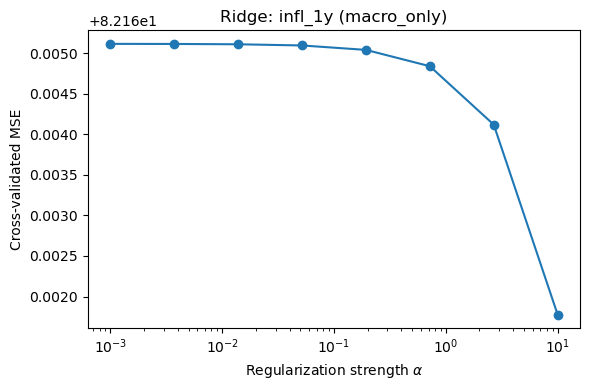

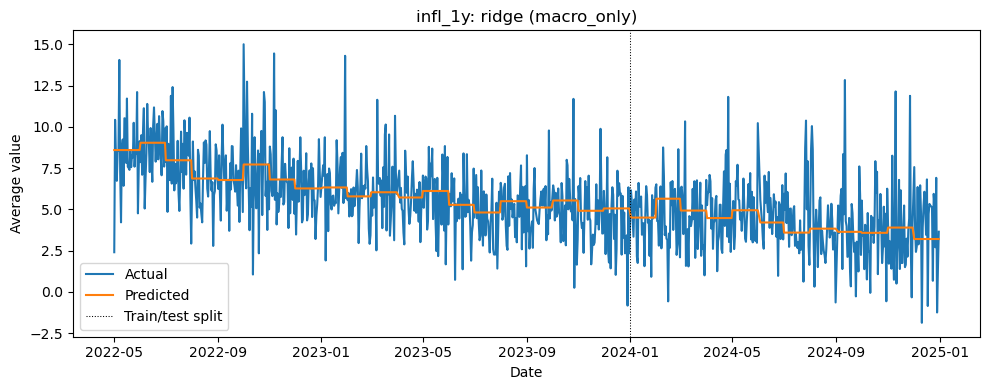

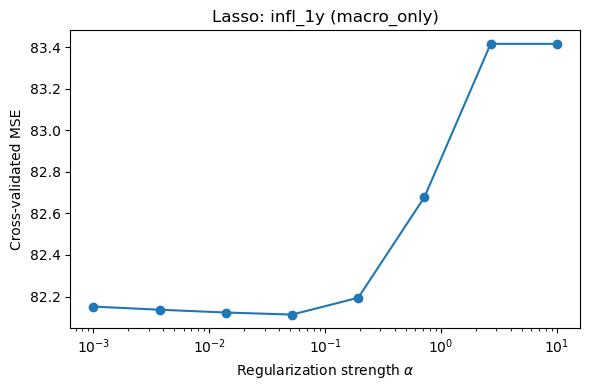

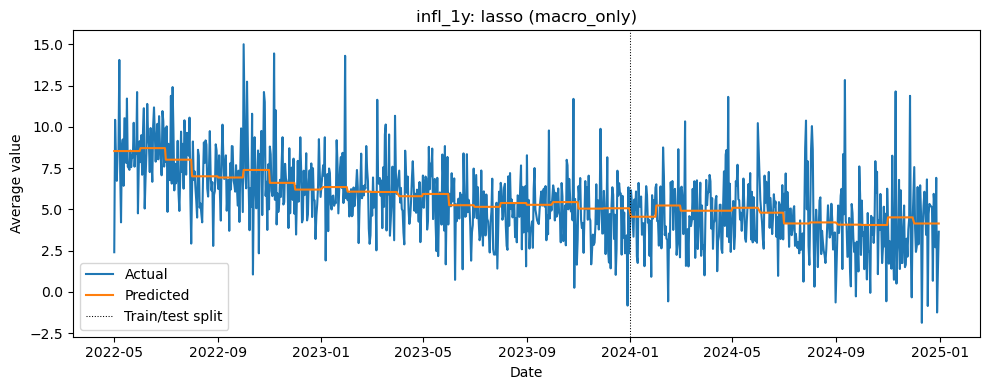

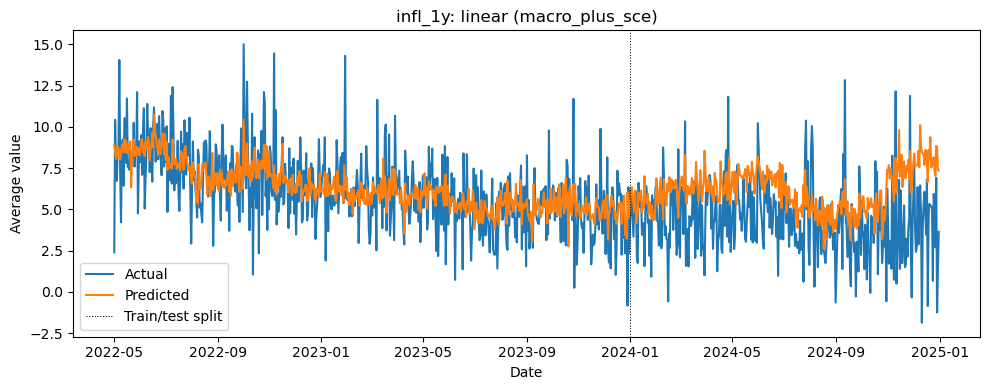

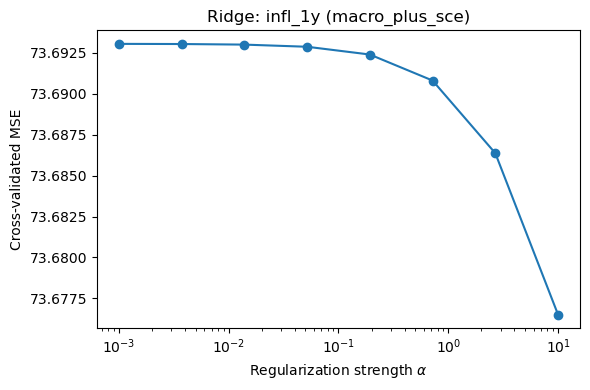

In [ ]:
results_infl_1y = fit_continuous_target('infl_1y')
results_infl_1y

In [ ]:
results_house_price_change = fit_continuous_target('house_price_change')
results_house_price_change

In [ ]:
results_prob_unrate_up = fit_continuous_target('prob_unrate_up')
results_prob_unrate_up

In [ ]:
results_prob_stocks_up = fit_continuous_target('prob_stocks_up')
results_prob_stocks_up

### Discussion

For each continuous expectations variable, we compare linear regression, Ridge, and Lasso using two different feature sets.

The `macro_only` specification shows how much predictive power can be obtained from macroeconomic and financial variables alone. The `macro_plus_sce` specification shows whether adding individual-level survey information improves the predictions.

We evaluate the models using RMSE and R² on the 2024 test sample. For Ridge and Lasso, we choose the regularization parameter using 5-fold cross-validation and plot the corresponding validation curve.

## Part 6 - Predicting binary optimism variables

In this part, we repeat the analysis from Part 5 for the binary optimism indicators:
- `optimist_unrate`
- `optimist_stocks`
- `optimist_house_price`

Since these are binary targets, this is a classification task. We estimate two models:
1. Logistic regression
2. Random forest

As in Part 5, we first use only macro/finance variables and then add a small set of individual-level SCE variables.

In [ ]:
# Imports used in Part 6
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegressionCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.model_selection import GridSearchCV

In [ ]:
# Binary target variables
target_vars_bin = [
    'optimist_unrate',
    'optimist_stocks',
    'optimist_house_price',
]

# Small hyperparameter grids to reduce computation time
logit_param_grid = {
    'model__C': np.logspace(-2, 1, 5),
}

rf_param_grid = {
    'model__n_estimators': [100, 200],
    'model__max_depth': [5, 10],
}

In [ ]:
def classifier_metrics(y_true, y_pred):
    """
    Compute classification metrics.
    """
    return {
        'accuracy': accuracy_score(y_true, y_pred),
        'precision': precision_score(y_true, y_pred, zero_division=0),
        'recall': recall_score(y_true, y_pred, zero_division=0),
        'f1': f1_score(y_true, y_pred, zero_division=0),
    }

In [ ]:
def make_classifier_pipeline(model_name, numeric_features, categorical_features):
    """
    Create preprocessing + classification pipeline.
    """
    # Logistic regression benefits from scaling; random forest does not
    if model_name == 'logit':
        num_transformer = StandardScaler()
        model = LogisticRegression(max_iter=100000, random_state=1234)
        param_grid = logit_param_grid
    elif model_name == 'forest':
        num_transformer = 'passthrough'
        model = RandomForestClassifier(random_state=1234)
        param_grid = rf_param_grid

    # Preprocessing step
    preprocessor = ColumnTransformer(
        transformers=[
            ('num', num_transformer, numeric_features),
            ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features),
        ],
        remainder='drop',
    )

    # Full pipeline
    pipe = Pipeline([
        ('preprocessor', preprocessor),
        ('model', model),
    ])

    return pipe, param_grid

In [ ]:
def plot_actual_vs_predicted_fraction(data, target, y_hat, model_name, feature_set_name):
    """
    Plot actual and predicted fractions of optimists over time.
    """
    # Temporary DataFrame with actual and predicted outcomes
    plot_data = data[['date', target]].copy()
    plot_data['y_hat'] = y_hat

    # Average by survey date gives the fraction optimistic
    ts = plot_data.groupby('date')[[target, 'y_hat']].mean()

    # Plot actual and predicted fractions
    plt.figure(figsize=(10, 4))
    plt.plot(ts.index, ts[target], label='Actual')
    plt.plot(ts.index, ts['y_hat'], label='Predicted')
    plt.axvline(train_end, ls=':', lw=0.75, c='black', label='Train/test split')
    plt.xlabel('Date')
    plt.ylabel('Fraction optimistic')
    plt.title(f'{target}: {model_name} ({feature_set_name})')
    plt.legend()
    plt.tight_layout()
    plt.show()

In [ ]:
def fit_binary_target(target):
    """
    Fit all Part 6 models for one binary target variable.
    """
    results = []

    # Loop over the two feature sets
    for feature_set_name, feature_set in feature_sets.items():

        # Keep only variables needed for this specification
        cols = ['date', target] + feature_set['numeric'] + feature_set['categorical']
        data = sce[cols].dropna().copy()

        # Regressors and target
        X = data[feature_set['numeric'] + feature_set['categorical']]
        y = data[target]

        # Train/test split
        train_mask = data['date'] < train_end
        test_mask = (data['date'] >= train_end) & (data['date'] < test_end)

        X_train = X.loc[train_mask]
        y_train = y.loc[train_mask]
        X_test = X.loc[test_mask]
        y_test = y.loc[test_mask]

        # Loop over models
        for model_name in ['logit', 'forest']:

            # Create pipeline
            pipe, param_grid = make_classifier_pipeline(
                model_name,
                feature_set['numeric'],
                feature_set['categorical'],
            )

            # Tune hyperparameters with cross-validation
            search = GridSearchCV(
                estimator=pipe,
                param_grid=param_grid,
                scoring='f1',
                cv=5,
                n_jobs=2,
            )
            search.fit(X_train, y_train)

            best_model = search.best_estimator_
            best_param = search.best_params_

            # Predictions
            y_train_hat = best_model.predict(X_train)
            y_test_hat = best_model.predict(X_test)
            y_hat = best_model.predict(X)

            # Metrics on training and test samples
            train_metrics = classifier_metrics(y_train, y_train_hat)
            test_metrics = classifier_metrics(y_test, y_test_hat)

            # Plot actual and predicted fractions over time
            plot_actual_vs_predicted_fraction(
                data,
                target,
                y_hat,
                model_name,
                feature_set_name,
            )

            # Store results
            results.append({
                'target': target,
                'feature_set': feature_set_name,
                'model': model_name,
                'best_param': str(best_param),
                'accuracy_train': train_metrics['accuracy'],
                'precision_train': train_metrics['precision'],
                'recall_train': train_metrics['recall'],
                'f1_train': train_metrics['f1'],
                'accuracy_test': test_metrics['accuracy'],
                'precision_test': test_metrics['precision'],
                'recall_test': test_metrics['recall'],
                'f1_test': test_metrics['f1'],
            })

    return pd.DataFrame(results)

In [ ]:
results_optimist_unrate = fit_binary_target('optimist_unrate')
results_optimist_unrate

In [ ]:
results_optimist_stocks = fit_binary_target('optimist_stocks')
results_optimist_stocks

In [ ]:
results_optimist_house_price = fit_binary_target('optimist_house_price')
results_optimist_house_price

## Discussion

For each binary optimism variable, we compare logistic regression and random forest using two different feature sets.

The `macro_only` specification shows how much predictive power can be obtained from aggregate macroeconomic and financial variables alone. The `macro_plus_sce` specification shows whether adding individual-level survey information improves predictive performance.

We evaluate the models using accuracy, precision, recall, and F1 on both the training and test samples, with the main comparison based on the 2024 test sample.

## Part 7 - Conclusion

In this term paper, we used survey data from the SCE together with macroeconomic and financial variables to predict household expectations.

For the continuous expectations variables, we compared linear regression, Ridge, and Lasso. For the binary optimism variables, we compared logistic regression and random forest. In both parts, we first used only macro/finance variables and then added a selected set of individual-level SCE variables.

The summary tables below compare model performance across all specifications. For the continuous variables, the main evaluation criteria are RMSE and R² on the 2024 test sample. For the binary variables, the main evaluation criteria are accuracy, precision, recall, and F1 on the 2024 test sample.

Overall, the results show whether macro/finance variables alone contain useful predictive information and whether adding individual-level survey variables leads to a meaningful improvement in predictive performance. The best-performing models differ across target variables, which suggests that different types of expectations may depend on different information sets.

In [ ]:
# Best results for continuous targets
summary_part5 = (
    results_part5
    .sort_values(['target', 'feature_set', 'rmse_test'])
    .groupby(['target', 'feature_set'], as_index=False)
    .first()
)

summary_part5 = summary_part5[
    ['target', 'feature_set', 'model', 'best_alpha', 'rmse_test', 'r2_test']
].round({
    'best_alpha': 4,
    'rmse_test': 4,
    'r2_test': 4,
})

summary_part5

In [ ]:
# Best results for binary targets
summary_part6 = (
    results_part6
    .sort_values(['target', 'feature_set', 'f1_test'], ascending=[True, True, False])
    .groupby(['target', 'feature_set'], as_index=False)
    .first()
)

summary_part6 = summary_part6[
    [
        'target',
        'feature_set',
        'model',
        'best_param',
        'accuracy_test',
        'precision_test',
        'recall_test',
        'f1_test',
    ]
].round({
    'accuracy_test': 3,
    'precision_test': 3,
    'recall_test': 3,
    'f1_test': 3,
})

summary_part6

## Final remarks

The results for the continuous variables show which model gives the lowest prediction error for each expectations variable. Comparing `macro_only` and `macro_plus_sce` also shows whether adding individual-level survey information improves performance relative to using aggregate macro/finance variables alone.

For the binary optimism variables, the classification results show which model provides the best balance between precision and recall, as summarized by the F1 score. Again, comparing the two feature sets makes it possible to assess whether individual-level SCE variables add predictive power.

Taken together, the results suggest that household expectations can be predicted to some extent using macroeconomic, financial, and survey information, but predictive performance differs across target variables and model classes.